In [1]:
import cv2
import matplotlib.pyplot as plt
import urllib.request
import numpy as np
import glob
import pandas as pd

Import Detector for localisation using YOLO V8

In [2]:
from vehicle_id.localisation.detector import detect_vehicles

Get raw sample images for Smokescreen test

In [17]:
def visualise_detections(image_path: str, weights: str = "yolov8n.pt"):
    results = detect_vehicles(image_path, weights=weights)

    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not read image at {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    for det in results:
        x1, y1, x2, y2 = map(int, det["bbox"])
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(image, f'{det["confidence"]:.2f}', (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title(image_path.split("/")[-1])
    plt.show()

    return results


image 1/1 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\notebooks\localisation\..\..\data\samples\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 29.8ms
Speed: 2.1ms preprocess, 29.8ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)


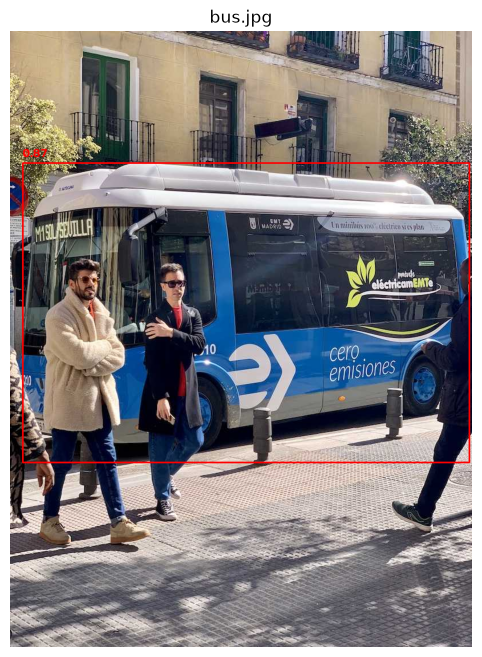

[{'bbox': (22.87126922607422,
   231.2772674560547,
   805.002685546875,
   756.8403930664062),
  'confidence': 0.8734484910964966}]

In [18]:
visualise_detections("../../data/samples/bus.jpg")

In [5]:
url = "https://cdn.upmove.com.au/image/blog/710647dba870546459affd96c976e0b3.jpeg"
save_path = "../../data/samples/aussie_road.jpg"
urllib.request.urlretrieve(url, save_path)

('../../data/samples/aussie_road.jpg',
 <http.client.HTTPMessage at 0x26b205fb360>)


image 1/1 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\notebooks\localisation\..\..\data\samples\aussie_road.jpg: 448x640 11 cars, 1 truck, 37.6ms
Speed: 1.7ms preprocess, 37.6ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)


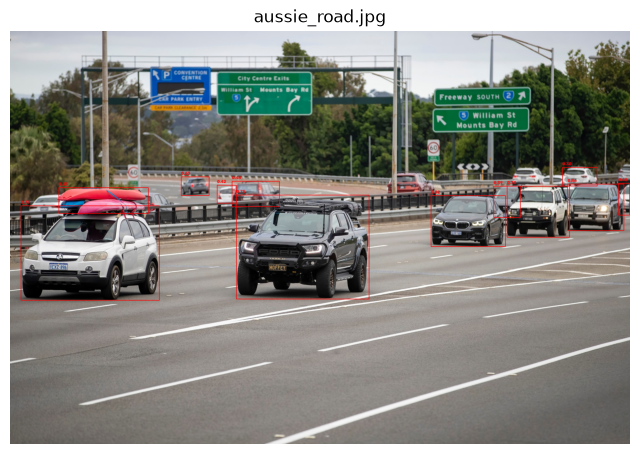

[{'bbox': (2698.8037109375,
   742.9720458984375,
   2970.534423828125,
   967.47021484375),
  'confidence': 0.8557849526405334},
 {'bbox': (2037.394287109375,
   798.8154907226562,
   2397.813720703125,
   1044.39599609375),
  'confidence': 0.8229808807373047},
 {'bbox': (53.08592224121094, 847.75, 722.405517578125, 1304.1011962890625),
  'confidence': 0.7673559784889221},
 {'bbox': (1095.8084716796875,
   795.128173828125,
   1737.662841796875,
   1298.7890625),
  'confidence': 0.7453214526176453},
 {'bbox': (2405.36083984375,
   752.5618286132812,
   2707.6279296875,
   999.4498901367188),
  'confidence': 0.7322907447814941},
 {'bbox': (828.1741333007812,
   707.5382080078125,
   963.27880859375,
   797.4473876953125),
  'confidence': 0.6312354207038879},
 {'bbox': (2944.685546875,
   738.90478515625,
   2998.932861328125,
   892.4776611328125),
  'confidence': 0.4814659357070923},
 {'bbox': (1074.3443603515625,
   728.52685546875,
   1303.8876953125,
   851.58935546875),
  'confide

In [6]:
visualise_detections("../../data/samples/aussie_road.jpg")

In [7]:
url = "https://media.drive.com.au/obj/tx_q:50,rs:auto:1920:1080:1/driveau/upload/cms/uploads/26cff4e8-d553-53f2-b428-837669150000"
save_path = "../../data/samples/blocked_car.jpg"
urllib.request.urlretrieve(url, save_path)

('../../data/samples/blocked_car.jpg',
 <http.client.HTTPMessage at 0x26b1a604830>)


image 1/1 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\notebooks\localisation\..\..\data\samples\blocked_car.jpg: 384x640 6 cars, 1 truck, 3 traffic lights, 40.0ms
Speed: 1.4ms preprocess, 40.0ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)


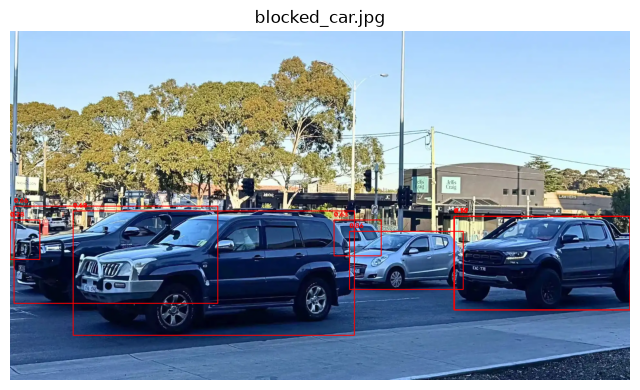

[{'bbox': (1051.337890625,
   619.5833740234375,
   1403.2138671875,
   799.0569458007812),
  'confidence': 0.8639540672302246},
 {'bbox': (1374.6844482421875,
   573.2488403320312,
   1919.3408203125,
   862.4031372070312),
  'confidence': 0.7029494047164917},
 {'bbox': (195.57705688476562,
   556.0699462890625,
   1066.6654052734375,
   941.500732421875),
  'confidence': 0.6827751398086548},
 {'bbox': (12.792205810546875,
   541.20068359375,
   643.3239135742188,
   842.1465454101562),
  'confidence': 0.6577883958816528},
 {'bbox': (1003.3595581054688,
   584.2086791992188,
   1149.751953125,
   695.3890380859375),
  'confidence': 0.6255174279212952},
 {'bbox': (1376.0223388671875,
   572.435302734375,
   1919.74267578125,
   863.5573120117188),
  'confidence': 0.5710093975067139},
 {'bbox': (0.561126708984375,
   584.652587890625,
   92.3681640625,
   706.2901611328125),
  'confidence': 0.2844342887401581}]

In [8]:
visualise_detections("../../data/samples/blocked_car.jpg")

In [9]:
url = "https://c8.alamy.com/comp/AWJYB8/cars-on-highway-high-angle-view-AWJYB8.jpg"
save_path = "../../data/samples/high_angle_cars.jpg"
urllib.request.urlretrieve(url, save_path)

('../../data/samples/high_angle_cars.jpg',
 <http.client.HTTPMessage at 0x26b206997b0>)


image 1/1 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\notebooks\localisation\..\..\data\samples\high_angle_cars.jpg: 640x448 1 person, 10 cars, 44.3ms
Speed: 1.6ms preprocess, 44.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 448)


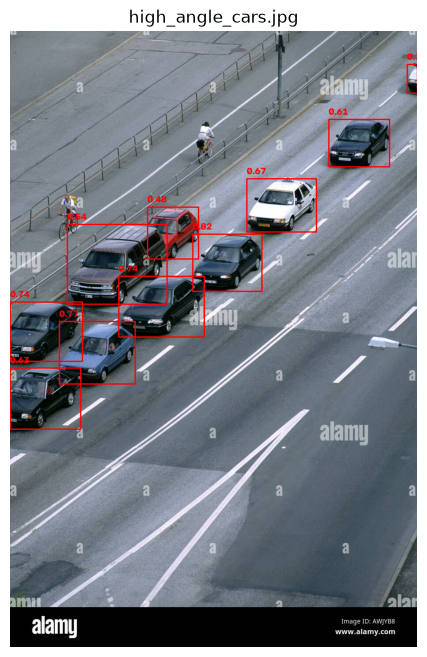

[{'bbox': (412.7332458496094,
   458.0982666015625,
   568.39501953125,
   587.72021484375),
  'confidence': 0.8238758444786072},
 {'bbox': (111.06317901611328,
   655.497314453125,
   282.6987609863281,
   796.276123046875),
  'confidence': 0.7744812965393066},
 {'bbox': (245.9904327392578,
   553.554931640625,
   438.3858947753906,
   690.3870239257812),
  'confidence': 0.7435415387153625},
 {'bbox': (0.0, 611.4031372070312, 163.42410278320312, 745.9102783203125),
  'confidence': 0.7379045486450195},
 {'bbox': (534.005126953125,
   333.50689697265625,
   691.0026245117188,
   453.25958251953125),
  'confidence': 0.6696775555610657},
 {'bbox': (0.038939714431762695,
   760.2329711914062,
   159.40892028808594,
   898.96044921875),
  'confidence': 0.6264440417289734},
 {'bbox': (719.4510498046875,
   199.96249389648438,
   856.0914916992188,
   306.700439453125),
  'confidence': 0.6085088849067688},
 {'bbox': (129.31524658203125,
   436.2261962890625,
   354.6408386230469,
   616.81219

In [10]:
visualise_detections("../../data/samples/high_angle_cars.jpg")

In [12]:
def evaluate_confidence(sample_dir: str = "../../data/samples", weights: str = "yolov8n.pt") -> pd.DataFrame:
  
    records = []

    for path in glob.glob(f"{sample_dir}/*.jpg"):
        results = detect_vehicles(path, weights=weights)  
        confidences = [det["confidence"] for det in results]

        records.append({
            "image": path.split("\\")[-1].split("/")[-1],
            "weights": weights,
            "num_detections": len(confidences),
            "mean_confidence": sum(confidences) / len(confidences) if confidences else 0,
            "min_confidence": min(confidences) if confidences else 0,
            "max_confidence": max(confidences) if confidences else 0,
        })

    df = pd.DataFrame(records)
    print(df)
    print("\nOverall summary:")
    print(f"Mean confidence across all images: {df['mean_confidence'].mean():.4f}")
    print(f"Total detections: {df['num_detections'].sum()}")

    return df

In [13]:
df_v8 = evaluate_confidence(weights="yolov8n.pt")


image 1/1 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\notebooks\localisation\..\..\data\samples\aussie_road.jpg: 448x640 11 cars, 1 truck, 25.5ms
Speed: 1.9ms preprocess, 25.5ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\notebooks\localisation\..\..\data\samples\blocked_car.jpg: 384x640 6 cars, 1 truck, 3 traffic lights, 21.8ms
Speed: 1.2ms preprocess, 21.8ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\notebooks\localisation\..\..\data\samples\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 27.0ms
Speed: 1.5ms preprocess, 27.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\notebooks\localisation\..\..\data\samples\high_angle_cars.jpg: 640x448 1 person, 10 car

Smokescreen with V8 seems to have relatively high confidence across varying traffic images.

In [ ]:
df_v26 = evaluate_confidence(weights="yolo26n.pt")


image 1/1 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\notebooks\localisation\..\..\data\samples\aussie_road.jpg: 448x640 11 cars, 1 truck, 40.3ms
Speed: 2.5ms preprocess, 40.3ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\notebooks\localisation\..\..\data\samples\blocked_car.jpg: 384x640 5 cars, 1 traffic light, 39.6ms
Speed: 1.7ms preprocess, 39.6ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\notebooks\localisation\..\..\data\samples\bus.jpg: 640x480 4 persons, 1 bus, 33.6ms
Speed: 1.9ms preprocess, 33.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\notebooks\localisation\..\..\data\samples\high_angle_cars.jpg: 640x448 2 persons, 9 cars, 31.6ms
Speed: 1.7ms 

In [15]:
merged = df_v8.merge(df_v26, on="image", suffixes=("_v8", "_v26"))
merged[["image", "mean_confidence_v8", "mean_confidence_v26", "num_detections_v8", "num_detections_v26"]]

,image,mean_confidence_v8,mean_confidence_v26,num_detections_v8,num_detections_v26
0,aussie_road.jpg,0.581197,0.517978,12,12
1,blocked_car.jpg,0.626918,0.782899,7,5
2,bus.jpg,0.873448,0.880600,1,1
3,high_angle_cars.jpg,0.632080,0.688192,10,9



image 1/1 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\notebooks\localisation\..\..\data\samples\blocked_car.jpg: 384x640 6 cars, 1 truck, 3 traffic lights, 24.7ms
Speed: 1.3ms preprocess, 24.7ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)


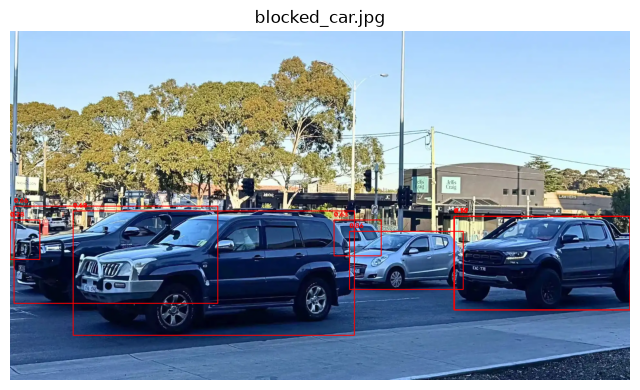


image 1/1 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\notebooks\localisation\..\..\data\samples\blocked_car.jpg: 384x640 5 cars, 1 traffic light, 25.7ms
Speed: 1.2ms preprocess, 25.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


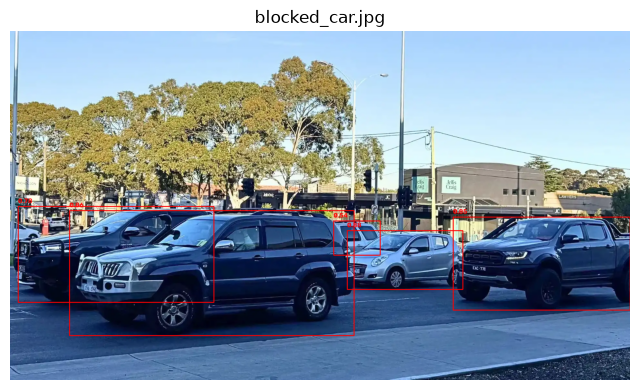

[{'bbox': (1044.2388916015625,
   617.13134765625,
   1402.0167236328125,
   799.2257690429688),
  'confidence': 0.8820276856422424},
 {'bbox': (184.8863525390625,
   555.8764038085938,
   1065.4638671875,
   942.8868408203125),
  'confidence': 0.8637356758117676},
 {'bbox': (1372.3719482421875, 575.4816284179688, 1920.0, 863.455810546875),
  'confidence': 0.8502070903778076},
 {'bbox': (25.023880004882812,
   542.9989013671875,
   631.6555786132812,
   839.90185546875),
  'confidence': 0.7773776054382324},
 {'bbox': (1002.3455200195312,
   587.029052734375,
   1146.03857421875,
   693.0452880859375),
  'confidence': 0.5411469340324402}]

In [19]:
visualise_detections("../../data/samples/blocked_car.jpg", weights="yolov8n.pt")
visualise_detections("../../data/samples/blocked_car.jpg", weights="yolo26n.pt")

Visually, v26 excluded that white car in the background whereas v8 did not. Leaving it out is better because the pixels is not enough to draw any meaningful insights 